In [28]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for cleaner, professional-looking plots
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load the dataset using the simple file name
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

#dataset structure and size
print("Dataset Shape:", df.shape)
print("\n First 3 Rows of the Dataset ")
display(df.head(3))

print("\n Dataset Information ")
df.info()

Dataset Shape: (135038, 17)

 First 3 Rows of the Dataset 


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA0K,Thurston,Tumwater,WA,98512.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,242565116,POINT (-122.91310169999997 47.01359260000004),PUGET SOUND ENERGY INC,5.306701e+10
1,1N4BZ1DV4N,Island,Clinton,WA,98236.0,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,183272785,POINT (-122.35936399999997 47.97965520000008),PUGET SOUND ENERGY INC,5.302997e+10
2,5YJ3E1EA0L,Snohomish,Snohomish,WA,98290.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,112552366,POINT (-122.09150499999998 47.91555500000004),PUGET SOUND ENERGY INC,5.306105e+10



 Dataset Information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         135038 non-null  object 
 1   County                                             135030 non-null  object 
 2   City                                               135030 non-null  object 
 3   State                                              135038 non-null  object 
 4   Postal Code                                        135030 non-null  float64
 5   Model Year                                         135038 non-null  int64  
 6   Make                                               135038 non-null  object 
 7   Model                                              134789 non-null  object 
 8   Electric Vehicle Type                              

In [27]:
#checking for missing values across all columns
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values[missing_values > 0])

#running basic descriptive statistics
print("\n Summary Statistics")
display(df[['Model Year', 'Electric Range', 'Base MSRP']].describe())

string_cols = ['Make', 'Model', 'Electric Vehicle Type', 'County', 'City']
for col in string_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()

print("\nData cleaning and verification complete! Ready for visualization.")

Missing Values per Column:
 County                    8
City                      8
Postal Code               8
Model                   249
Electric Range            1
Base MSRP                 1
Legislative District    312
Vehicle Location         10
Electric Utility          8
2020 Census Tract         8
dtype: int64

--- Summary Statistics ---


,Model Year,Electric Range,Base MSRP
count,135038.000000,135037.000000,135037.000000
mean,2019.662880,74.591964,1448.407325
std,3.001676,98.744120,9683.658138
min,1997.000000,0.000000,0.000000
25%,2018.000000,0.000000,0.000000
50%,2021.000000,21.000000,0.000000
75%,2022.000000,150.000000,0.000000
max,2024.000000,337.000000,845000.000000



Data cleaning and verification complete! Ready for visualization.


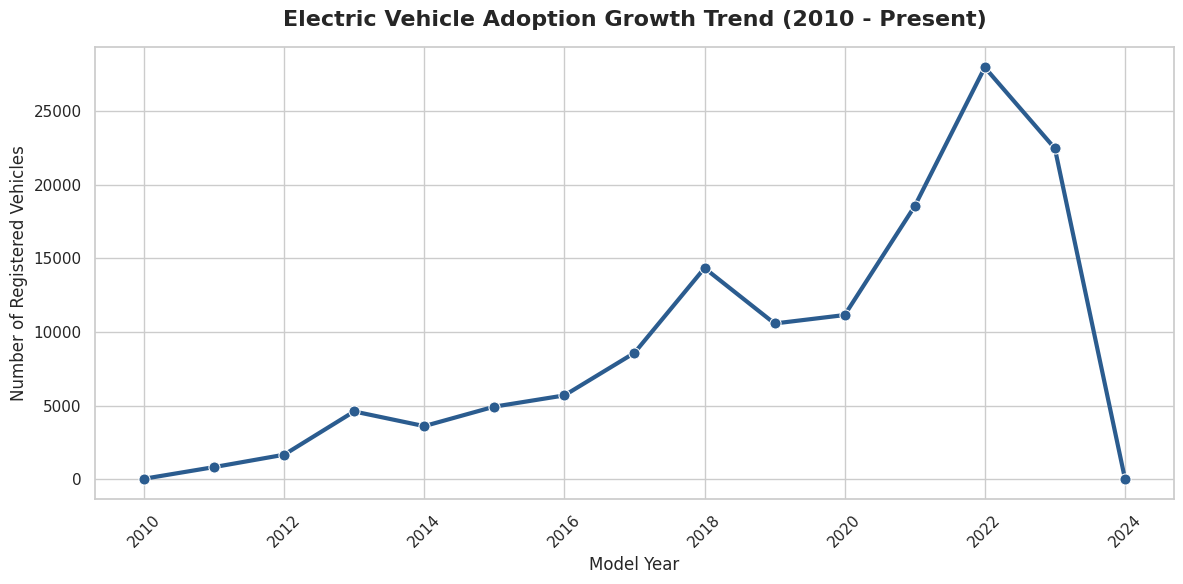

In [26]:
#filtering extremely old or outlier
trend_df = df[df['Model Year'] >= 2010]

# Group by Model Year to count registrations
yearly_growth = trend_df.groupby('Model Year').size().reset_index(name='Vehicle Count')

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=yearly_growth,
    x='Model Year',
    y='Vehicle Count',
    marker='o',
    linewidth=3,
    color='#2b5c8f',
    markersize=8
)

plt.title('Electric Vehicle Adoption Growth Trend (2010 - Present)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Number of Registered Vehicles', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1042/345278464.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


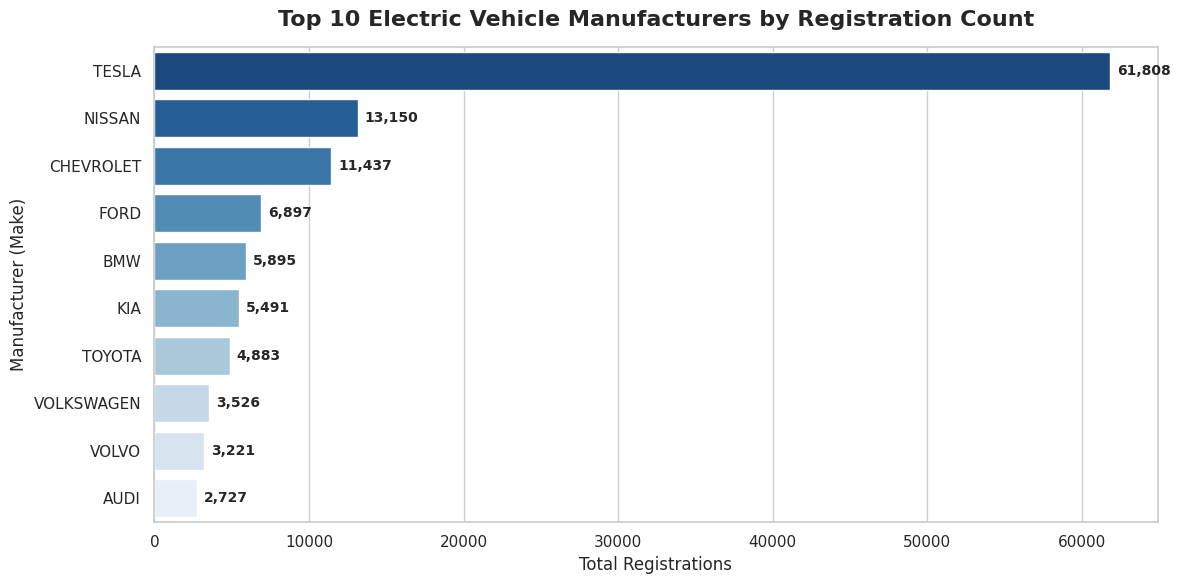

In [29]:
#10 most popular vehicle makes
top_makes = df['Make'].value_counts().head(10).reset_index()
top_makes.columns = ['Make', 'Count']

#top manufacturers
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_makes,
    x='Count',
    y='Make',
    palette='Blues_r'
)

plt.title('Top 10 Electric Vehicle Manufacturers by Registration Count', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Registrations', fontsize=12)
plt.ylabel('Manufacturer (Make)', fontsize=12)

#increasing readability
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width):,}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        fontweight='semibold'
    )

plt.tight_layout()
plt.show()

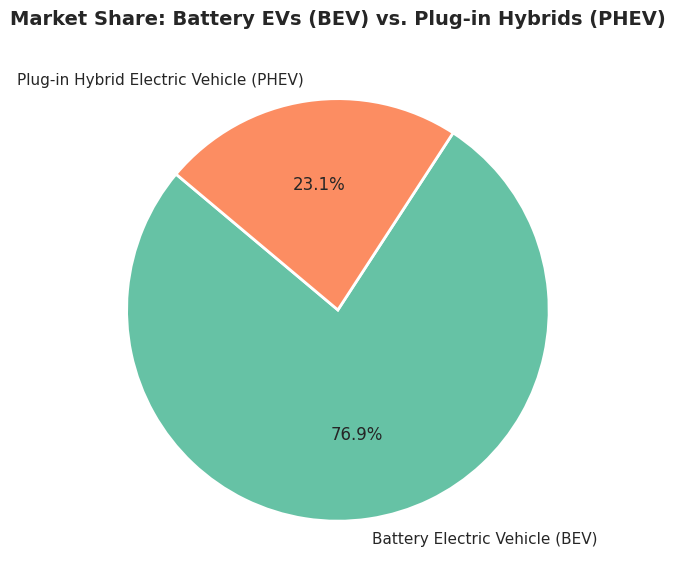

In [30]:
#counting the distribution of EV types
ev_type_counts = df['Electric Vehicle Type'].value_counts().reset_index()
ev_type_counts.columns = ['Electric Vehicle Type', 'Count']

plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set2")

plt.pie(
    ev_type_counts['Count'],
    labels=ev_type_counts['Electric Vehicle Type'],
    autopct='%1.1f%%',
    startangle=140,
    colors=palette[:len(ev_type_counts)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Market Share: Battery EVs (BEV) vs. Plug-in Hybrids (PHEV)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1042/633232072.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


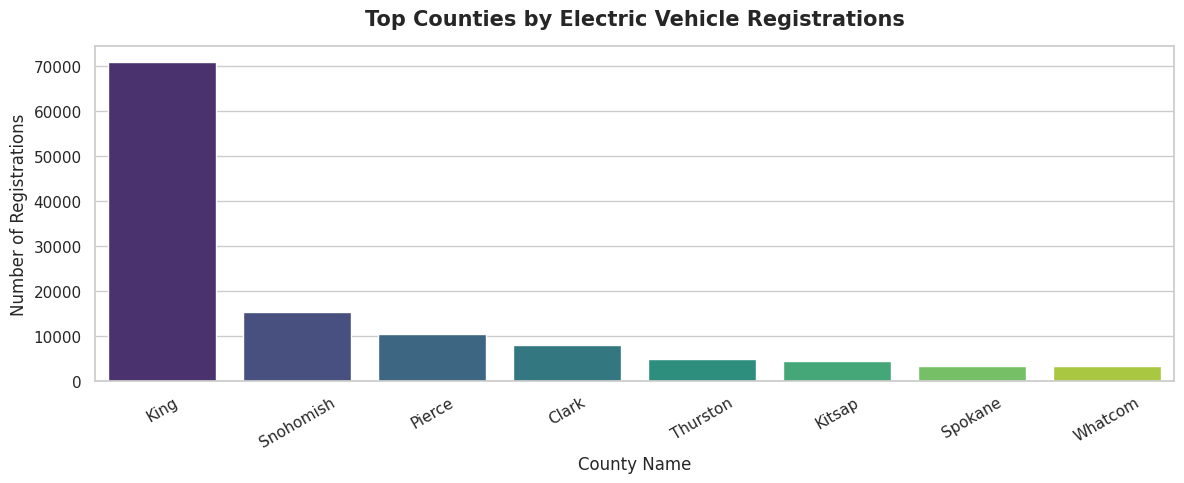

In [31]:
#top 8 counties with highest EV registrations
top_counties = df['County'].value_counts().head(8).reset_index()
top_counties.columns = ['County', 'Registration Count']

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=top_counties,
    x='County',
    y='Registration Count',
    palette='viridis'
)

plt.title('Top Counties by Electric Vehicle Registrations', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('County Name', fontsize=12)
plt.ylabel('Number of Registrations', fontsize=12)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

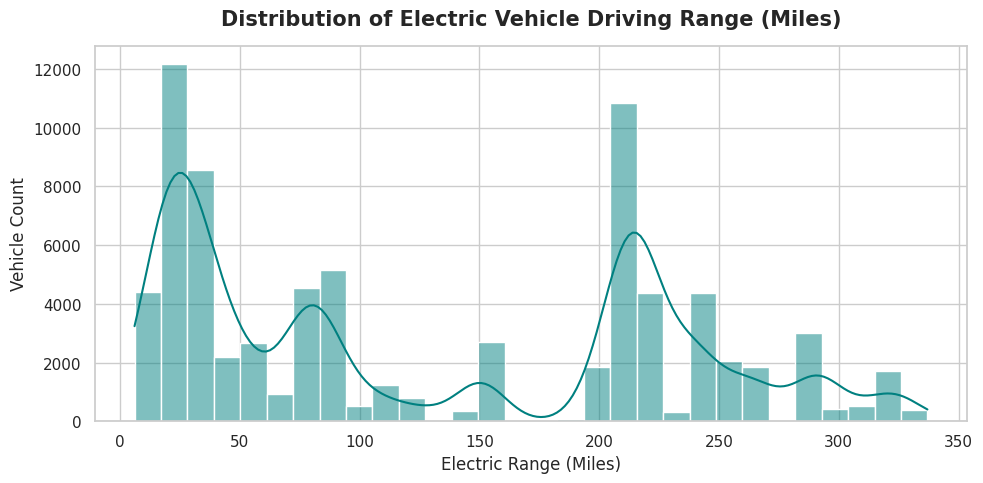

In [32]:
#filtering out zero ranges
range_df = df[df['Electric Range'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=range_df,
    x='Electric Range',
    bins=30,
    kde=True,
    color='teal'
)

plt.title('Distribution of Electric Vehicle Driving Range (Miles)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Electric Range (Miles)', fontsize=12)
plt.ylabel('Vehicle Count', fontsize=12)

plt.tight_layout()
plt.show()